# Análisis de Sentimiento

Determinamos qué palabras son positivas, negativas o neutras, y con eso calculamos qué tan
positivo o negativo es cada tweet.

Usamos **VADER** (`nltk.sentiment.vader`), un analizador basado en léxico y reglas pensado
para texto de redes sociales. Cada término de su léxico trae una valencia de -4 a +4
asignada por anotadores humanos. Lo elegimos sobre alternativas como TextBlob porque además
del léxico aplica reglas que importan en tweets: negación, intensificadores, mayúsculas
sostenidas, signos de exclamación repetidos y emoticones.

In [1]:
import sys
sys.path.append('..')

import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.sentimiento import (
    analizador, preparar, clasificar_lexicon, contar_palabras,
    analizar_tweet, analizar_dataframe, palabras_del_corpus, UMBRAL_NEUTRO,
)
from src.limpieza import clean_text, remove_urls

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 70)

raw = pd.read_csv('../data/raw/train.csv')
print(f'{len(raw)} tweets crudos')

7613 tweets crudos


## 1. Sobre qué texto se calcula el sentimiento

La primera decisión es si analizar el texto crudo o el limpio del inciso 3. Parece un detalle
de implementación, pero determina el resultado por completo.

La limpieza elimina stopwords usando la lista de NLTK, y **20 de las 59 negaciones que VADER
reconoce son stopwords**. Al quitarlas, la polaridad del tweet se invierte.

In [2]:
from nltk.sentiment.vader import VaderConstants
from nltk.corpus import stopwords

NEGACIONES = set(VaderConstants.NEGATE)
perdidas = sorted(NEGACIONES & set(stopwords.words('english')))

print(f'Negaciones que VADER reconoce: {len(NEGACIONES)}')
print(f'De ellas, eliminadas por la limpieza: {len(perdidas)}\n')
print(', '.join(perdidas))

sin_url = [remove_urls(str(t)) for t in raw['text']]
afectados = sum(1 for t in sin_url if any(w.strip('.,!?') in NEGACIONES for w in t.lower().split()))
print(f'\nTweets del dataset que contienen alguna negación: {afectados} ({afectados/len(raw):.2%})')

Negaciones que VADER reconoce: 59
De ellas, eliminadas por la limpieza: 20

aren't, couldn't, didn't, doesn't, don't, hadn't, hasn't, haven't, isn't, mightn't, mustn't, needn't, nor, not, shan't, shouldn't, wasn't, weren't, won't, wouldn't

Tweets del dataset que contienen alguna negación: 857 (11.26%)


In [3]:
sa = analizador()
ejemplos = ['this is not good at all', 'no survivors found', 'never seen anything this bad']

comparacion = []
for texto in ejemplos:
    limpio = clean_text(texto)
    comparacion.append({
        'texto crudo': texto,
        'compound crudo': round(sa.polarity_scores(texto)['compound'], 4),
        'texto limpio': limpio,
        'compound limpio': round(sa.polarity_scores(limpio)['compound'], 4),
    })

display(pd.DataFrame(comparacion))

,texto crudo,compound crudo,texto limpio,compound limpio
0,this is not good at all,-0.3412,good,0.4404
1,no survivors found,-0.2960,survivors found,0.0000
2,never seen anything this bad,-0.6280,never seen anything bad,0.4310


En los tres casos el signo se invierte. `"never seen anything this bad"` pasa de -0.628 a
+0.431 simplemente porque `never` desapareció.

Por eso el sentimiento se calcula sobre el **texto crudo**, al que solo le quitamos URLs y
artefactos de codificación. Se conservan a propósito las mayúsculas, la puntuación, las
negaciones y los emoticones, porque VADER los usa como señal. Es un pipeline distinto al del
inciso 3, y con un objetivo distinto: aquel buscaba reducir el vocabulario para el
clasificador, este busca preservar la carga emocional.

## 2. ¿Vale la pena conservar los emoticones?

El enunciado pregunta si conviene dejar los emoticones y analizarlos. Lo medimos sobre el
dataset en lugar de responder de memoria.

In [4]:
emoticon_re = re.compile(r"(?<![\w/])[:;=8]-?[\)\(\]\[DPpOo3/\\|]|<3|\^_\^")
emoji_re = re.compile('[\U0001F300-\U0001FAFF☀-➿]')

con_emoticon = [t for t in sin_url if emoticon_re.search(t)]
con_emoji = [t for t in raw['text'].astype(str) if emoji_re.search(t)]
no_ascii = [t for t in raw['text'].astype(str) if any(ord(c) > 127 for c in t)]

print(f'Tweets con emoticones ASCII :  {len(con_emoticon):5d} ({len(con_emoticon)/len(raw):6.2%})')
print(f'Tweets con emojis Unicode   :  {len(con_emoji):5d} ({len(con_emoji)/len(raw):6.2%})')
print(f'Tweets con algún no-ASCII   :  {len(no_ascii):5d} ({len(no_ascii)/len(raw):6.2%})')

print('\nCaracteres no-ASCII más frecuentes:')
print(pd.Series([c for t in raw['text'].astype(str) for c in t if ord(c) > 127]).value_counts().head(6).to_dict())

Tweets con emoticones ASCII :     95 ( 1.25%)
Tweets con emojis Unicode   :      0 ( 0.00%)
Tweets con algún no-ASCII   :    697 ( 9.16%)

Caracteres no-ASCII más frecuentes:
{'\x89': 797, 'Û': 794, 'ª': 191, 'å': 96, 'Ï': 69, 'Ê': 66}


El dataset **no contiene un solo emoji**. El 9% de tweets con caracteres no-ASCII resulta
ser mojibake: secuencias como `\x89`, `Û` y `ª` producidas por una conversión defectuosa
entre CP1252 y UTF-8 en algún punto de la recolección. No son emojis eliminados, son basura
de codificación.

Eso reencuadra la pregunta. El paso `remove_emojis` del inciso 3, que codifica a ASCII, en
realidad nunca quitó emojis en este corpus: lo que quitó fue el mojibake, y hace bien.

In [5]:
muestra = [t.strip() for t in con_emoticon[:6]]
for t in muestra:
    p = sa.polarity_scores(t)['compound']
    sin_emo = emoticon_re.sub('', t).strip()
    p_sin = sa.polarity_scores(sin_emo)['compound']
    print(f'{t[:58]:60s} con={p:+.4f}  sin={p_sin:+.4f}  Δ={p-p_sin:+.4f}')

London is cool ;)                                            con=+0.4939  sin=+0.3182  Δ=+0.1757
Cooool :)                                                    con=+0.4588  sin=+0.0000  Δ=+0.4588
Ablaze for you Lord :D                                       con=+0.6166  sin=+0.0000  Δ=+0.6166
I-77 Mile Marker 31 South Mooresville  Iredell Vehicle Acc   con=-0.4767  sin=-0.4767  Δ=+0.0000
I-77 Mile Marker 31 to 40 South Mooresville  Iredell Vehic   con=-0.4767  sin=-0.4767  Δ=+0.0000
8/6/2015@2:09 PM: TRAFFIC ACCIDENT NO INJURY at 2781 WILLI   con=-0.8833  sin=-0.8833  Δ=+0.0000


Los emoticones ASCII sí aportan: VADER los tiene en su léxico y modifican la puntuación,
como se ve en la columna Δ. Pero aparecen en solo **95 tweets, el 1.25% del corpus**, así
que su efecto agregado es marginal.

**Respuesta a la pregunta del enunciado:** sí vale la pena conservarlos, porque no cuesta
nada y en esos 95 tweets aportan señal real. Pero el hallazgo importante de esta sección es
otro: lo que de verdad había que rescatar del preprocesamiento no eran los emoticones sino
**las negaciones**, que afectan al 11.26% de los tweets e invierten el signo del resultado.
Los emoticones eran la pregunta visible; las negaciones eran el problema.

## 3. Palabras positivas, negativas y neutras

El léxico de VADER solo almacena términos con carga emocional. Todo lo que no aparece en él
se considera neutro por omisión, que es por lo que la categoría neutra sale vacía al
clasificar el léxico en sí.

In [6]:
lexicon = clasificar_lexicon()
print('Composición del léxico de VADER:')
print(lexicon['polaridad'].value_counts().to_string())
print(f'\nTotal: {len(lexicon)} términos con carga de sentimiento')

print('\nLas 10 palabras más negativas del léxico:')
display(lexicon.head(10)[['palabra', 'valencia']].T)
print('Las 10 palabras más positivas del léxico:')
display(lexicon.tail(10)[['palabra', 'valencia']].iloc[::-1].T)

Composición del léxico de VADER:
polaridad
negativa    4169
positiva    3333
neutra         0

Total: 7502 términos con carga de sentimiento

Las 10 palabras más negativas del léxico:


,0,1,2,3,4,5,6,7,8,9
palabra,rapist,raping,slavery,rape,kill,terrorist,fu,murder,motherfucker,hatefulness
valencia,-3.9,-3.8,-3.8,-3.7,-3.7,-3.7,-3.7,-3.7,-3.6,-3.6


Las 10 palabras más positivas del léxico:


,7501,7500,7499,7498,7497,7496,7495,7494,7493,7492
palabra,aml,ilu,ily,magnificently,ecstacy,sweetheart,euphoria,lya,love,143
valencia,3.4,3.4,3.4,3.4,3.3,3.3,3.3,3.3,3.2,3.2


Más útil que el léxico completo es ver qué palabras con carga emocional usa realmente
nuestro corpus, y con qué frecuencia.

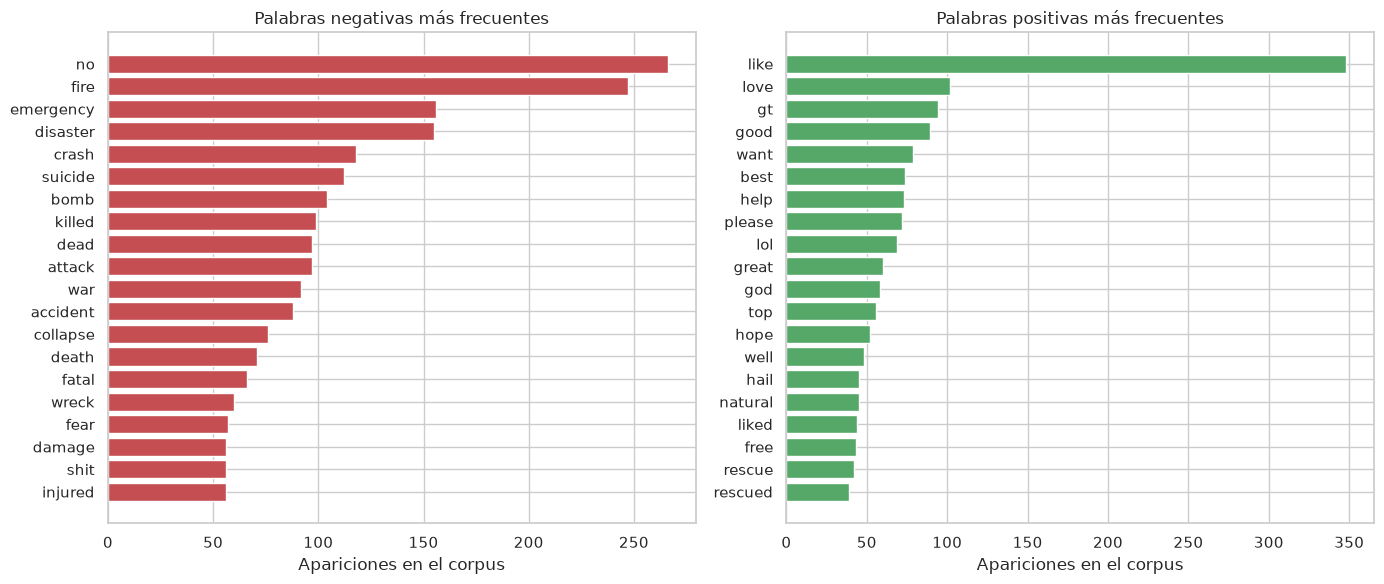

,palabra_neg,frecuencia_neg,valencia_neg,palabra_pos,frecuencia_pos,valencia_pos
0,no,266,-1.2,like,348,1.5
1,fire,247,-1.4,love,102,3.2
2,emergency,156,-1.6,gt,94,1.1
3,disaster,155,-3.1,good,89,1.9
4,crash,118,-1.7,want,79,0.3
5,suicide,112,-3.5,best,74,3.2
6,bomb,104,-2.2,help,73,1.7
7,killed,99,-3.5,please,72,1.3
8,dead,97,-3.3,lol,69,1.8
9,attack,97,-2.1,great,60,3.1


In [7]:
corpus = palabras_del_corpus(raw, top_n=20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, clave, color, titulo in [
    (axes[0], 'negativas', '#C44E52', 'Palabras negativas más frecuentes'),
    (axes[1], 'positivas', '#55A868', 'Palabras positivas más frecuentes'),
]:
    d = corpus[clave].iloc[::-1]
    ax.barh(d['palabra'], d['frecuencia'], color=color)
    ax.set_title(titulo)
    ax.set_xlabel('Apariciones en el corpus')
plt.tight_layout()
plt.show()

display(corpus['negativas'].head(10).merge(
    corpus['positivas'].head(10), left_index=True, right_index=True,
    suffixes=('_neg', '_pos')))

El vocabulario negativo del corpus está dominado por términos de catástrofe (`fire`,
`disaster`, `emergency`, `killed`, `crash`), coherente con que casi la mitad del dataset
describe desastres. El positivo es más genérico y conversacional (`like`, `love`, `good`,
`best`).

Vale notar que `fire` aparece como negativa con valencia -1.4. Es la misma ambigüedad que
viene arrastrándose desde el análisis de frecuencias: en la clase no-desastre `fire` se usa
como elogio, y el léxico no lo distingue.

## 4. Puntuación del tweet a partir del conteo de palabras

El enunciado pide determinar qué tan positivo o negativo es cada tweet **a partir de la
cantidad de palabras positivas y negativas que contiene**. Implementamos ese conteo directo:

$$\text{score} = \frac{n_{pos} - n_{neg}}{n_{pos} + n_{neg}}$$

El resultado queda en [-1, 1], y se etiqueta como positivo, negativo o neutral según caiga
fuera o dentro de la banda ±0.05.

In [8]:
for texto in ['Massive earthquake kills hundreds in Nepal',
              'Beautiful sunset at the beach today, feeling blessed',
              'this is not good at all']:
    r = analizar_tweet(texto)
    print(f'{texto!r}')
    print(f"  positivas ({r['n_positivas']}): {r['palabras_positivas']}")
    print(f"  negativas ({r['n_negativas']}): {r['palabras_negativas']}")
    print(f"  score por conteo : {r['score_conteo']:+.3f} → {r['etiqueta_conteo']}")
    print(f"  compound de VADER: {r['compound']:+.3f} → {r['etiqueta_vader']}\n")

'Massive earthquake kills hundreds in Nepal'
  positivas (0): []
  negativas (1): ['kills']
  score por conteo : -1.000 → negativo
  compound de VADER: -0.542 → negativo

'Beautiful sunset at the beach today, feeling blessed'
  positivas (3): ['beautiful', 'feeling', 'blessed']
  negativas (0): []
  score por conteo : +1.000 → positivo
  compound de VADER: +0.852 → positivo

'this is not good at all'
  positivas (1): ['good']
  negativas (0): []
  score por conteo : +1.000 → positivo
  compound de VADER: -0.341 → negativo



El tercer caso muestra la limitación del conteo puro: `"this is not good at all"` contiene
una sola palabra del léxico, `good`, así que el conteo lo declara **positivo**. VADER lee la
negación previa y lo declara **negativo**, que es lo correcto.

Mantenemos ambas medidas: el conteo porque es lo que pide el enunciado y es transparente, y
el `compound` de VADER porque corrige justamente los casos donde el conteo se equivoca.

## 5. Aplicación a todo el corpus

In [9]:
df = analizar_dataframe(raw)
df.to_csv('../data/cleaned/train_sentimiento.csv', index=False)
print(f'{len(df)} tweets analizados\n')
display(df[['text', 'n_positivas', 'n_negativas', 'score_conteo',
            'etiqueta_conteo', 'compound', 'etiqueta_vader']].head())

7613 tweets analizados



,text,n_positivas,n_negativas,score_conteo,etiqueta_conteo,compound,etiqueta_vader
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1,0,1.0,positivo,0.2732,positivo
1,Forest fire near La Ronge Sask. Canada,0,1,-1.0,negativo,-0.3400,negativo
2,All residents asked to 'shelter in place' are being notified by of...,0,1,-1.0,negativo,-0.2960,negativo
3,"13,000 people receive #wildfires evacuation orders in California",0,0,0.0,neutral,0.0000,neutral
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfire...,0,0,0.0,neutral,0.0000,neutral


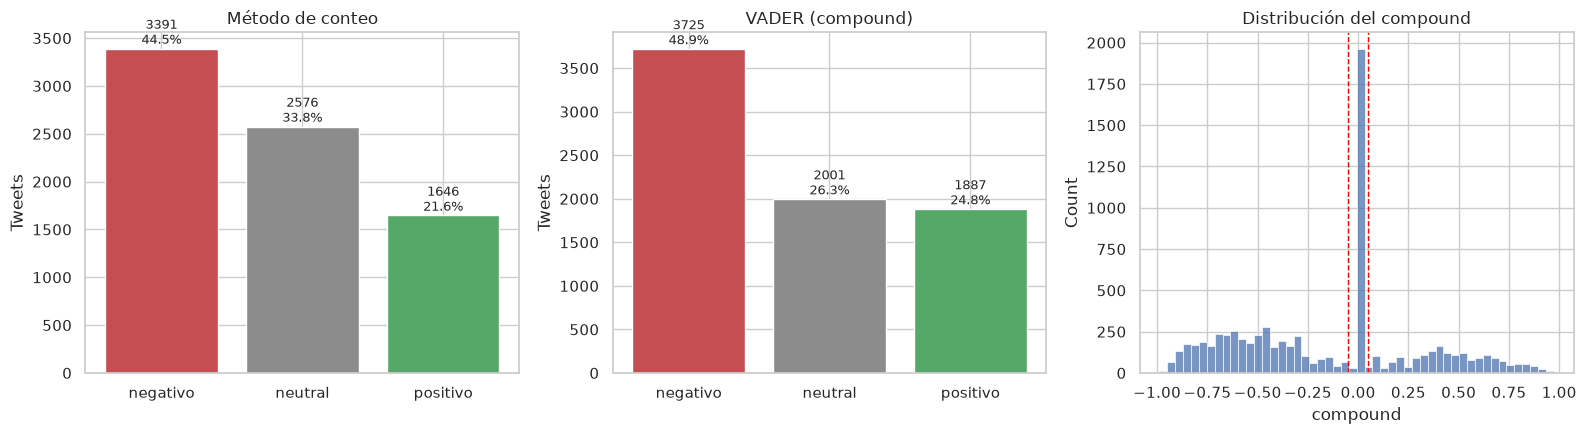

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

orden = ['negativo', 'neutral', 'positivo']
colores = ['#C44E52', '#8C8C8C', '#55A868']

for ax, col, titulo in [(axes[0], 'etiqueta_conteo', 'Método de conteo'),
                        (axes[1], 'etiqueta_vader', 'VADER (compound)')]:
    v = df[col].value_counts().reindex(orden)
    ax.bar(orden, v.values, color=colores)
    ax.set_title(titulo)
    ax.set_ylabel('Tweets')
    for i, n in enumerate(v.values):
        ax.text(i, n + 50, f'{n}\n{n/len(df):.1%}', ha='center', fontsize=9)

sns.histplot(df['compound'], bins=50, ax=axes[2], color='#4C72B0')
axes[2].axvline(-UMBRAL_NEUTRO, color='red', ls='--', lw=1)
axes[2].axvline(UMBRAL_NEUTRO, color='red', ls='--', lw=1)
axes[2].set_title('Distribución del compound')
axes[2].set_xlabel('compound')

plt.tight_layout()
plt.show()

In [11]:
concordancia = (df['etiqueta_conteo'] == df['etiqueta_vader']).mean()
print(f'Los dos métodos coinciden en {concordancia:.1%} de los tweets\n')
display(pd.crosstab(df['etiqueta_conteo'], df['etiqueta_vader'],
                    rownames=['conteo'], colnames=['VADER']))

Los dos métodos coinciden en 83.4% de los tweets



VADER,negativo,neutral,positivo
conteo,,,
negativo,3149,115,127
neutral,469,1775,332
positivo,107,111,1428


Los métodos coinciden en el 83.4% de los casos. Donde más difieren es en la banda neutral:
el conteo declara neutrales bastantes tweets que VADER sí carga, porque el conteo ignora los
intensificadores y el énfasis de puntuación y mayúsculas.

La distribución del `compound` es marcadamente bimodal, con acumulación en los extremos y un
pico en cero. Ese pico son los tweets sin ninguna palabra del léxico, que salen neutrales por
ausencia de evidencia y no por equilibrio entre carga positiva y negativa.

## 6. Conclusiones

- **El sentimiento se calcula sobre texto crudo**, no sobre el limpio del inciso 3. La
  limpieza elimina 20 de las 59 negaciones de VADER, lo que invierte el signo del resultado
  en el 11.26% de los tweets que las contienen.
- **Sobre los emoticones:** sí conviene conservarlos, VADER los puntúa y modifican el
  resultado. Pero solo aparecen en 95 tweets (1.25%), así que su efecto agregado es menor.
  El dataset no contiene ningún emoji Unicode; lo que parecían emojis es mojibake por una
  conversión defectuosa de codificación.
- **Palabras clasificadas:** el léxico de VADER aporta 4,169 términos negativos y 3,333
  positivos. En nuestro corpus predominan los negativos de catástrofe.
- **Puntuación por tweet:** se calculó por conteo de palabras positivas y negativas, como
  pide el enunciado, y en paralelo con el `compound` de VADER. Coinciden en el 83.4% de los
  casos; donde difieren, VADER acierta más porque interpreta la negación.
- El corpus resulta predominantemente negativo: 48.9% de los tweets según VADER, contra
  24.8% positivos y 26.3% neutrales.

El archivo `data/cleaned/train_sentimiento.csv` queda con todas las columnas de sentimiento
para el análisis por categoría del siguiente ejercicio.